# Full Model — Random Forest & Gradient Boosting

Compare ensemble models against the baselines, using time-based split and cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [18]:
df = pd.read_csv("./data/final_merged_data_rain_plus_crop_yield.csv")
print(f"Loaded: {df.shape}")

Loaded: (19439, 23)


## 1. Feature Preparation

In [19]:
X = df.drop(columns=["Yield", "Production", "Area"])
y = df["Yield"]

label_encoders = {}
for col in ["District", "Crop", "Season"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print(f"Features: {list(X.columns)}")

Features: ['District', 'Year', 'Crop', 'Season', 'Yield_Lag1', 'Yield_Lag2', 'Yield_3yr_Avg', 'Yield_3yr_Std', 'june_normal_rainfall', 'june_actual_rainfall', 'june_percent_to_normal', 'july_normal_rainfall', 'july_actual_rainfall', 'july_percent_to_normal', 'august_normal_rainfall', 'august_actual_rainfall', 'august_percent_to_normal', 'september_normal_rainfall', 'september_actual_rainfall', 'september_percent_to_normal']


## 2. Time-Based Train/Test Split

For time-series data, we train on the past and test on the future to avoid data leakage.

In [20]:
# Time-based split: train on 1998-2018, test on 2019-2022
train_mask = X['Year'] <= 2018
test_mask = X['Year'] > 2018

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape[0]} samples (1998-2018)")
print(f"Test:  {X_test.shape[0]} samples (2019-2022)")

Train: 15758 samples (1998-2018)
Test:  3681 samples (2019-2022)


### 3. Train All 3 Models

In [21]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    # 'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42, max_depth=5)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results.append({'Model': name, 'R²': round(r2,4), 'RMSE': round(rmse,4), 'MAE': round(mae,4)})
    print(f"{name:25s} | R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

Linear Regression         | R²: 0.5944 | RMSE: 0.6241 | MAE: 0.2531
Ridge Regression          | R²: 0.5944 | RMSE: 0.6241 | MAE: 0.2531
Gradient Boosting         | R²: 0.6783 | RMSE: 0.5559 | MAE: 0.0788


## 4. Model Comparison Table

            Model     R²   RMSE    MAE
Linear Regression 0.5944 0.6241 0.2531
 Ridge Regression 0.5944 0.6241 0.2531
Gradient Boosting 0.6783 0.5559 0.0788


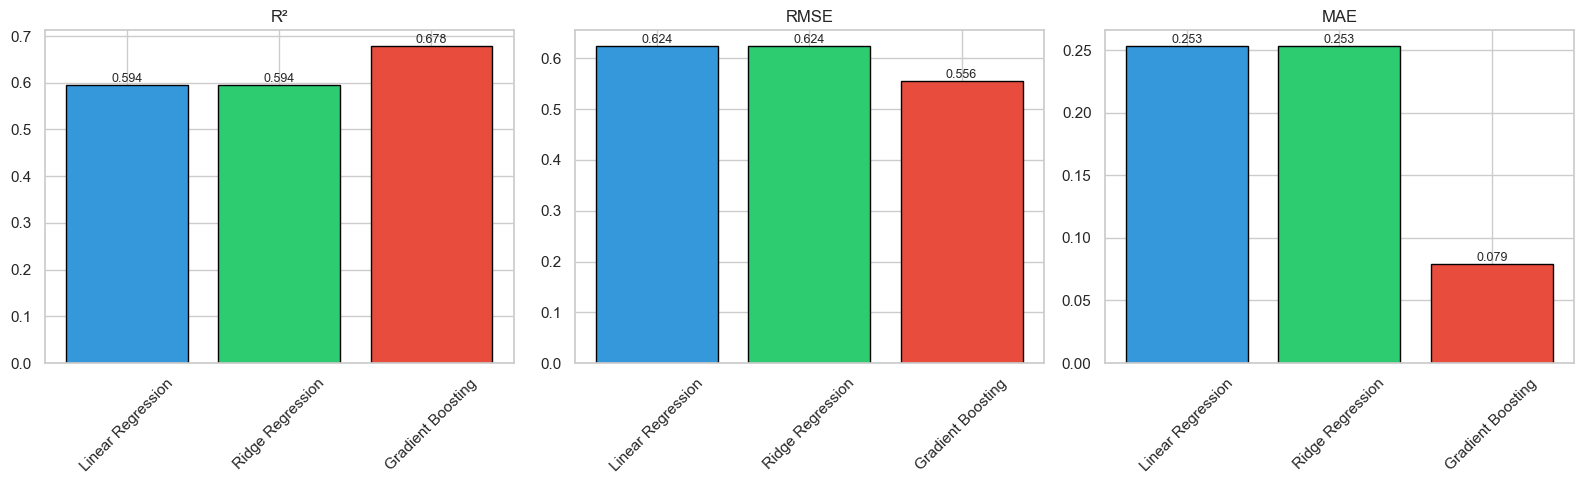

In [22]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, edgecolor='black')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Predicted vs Actual — Best Model

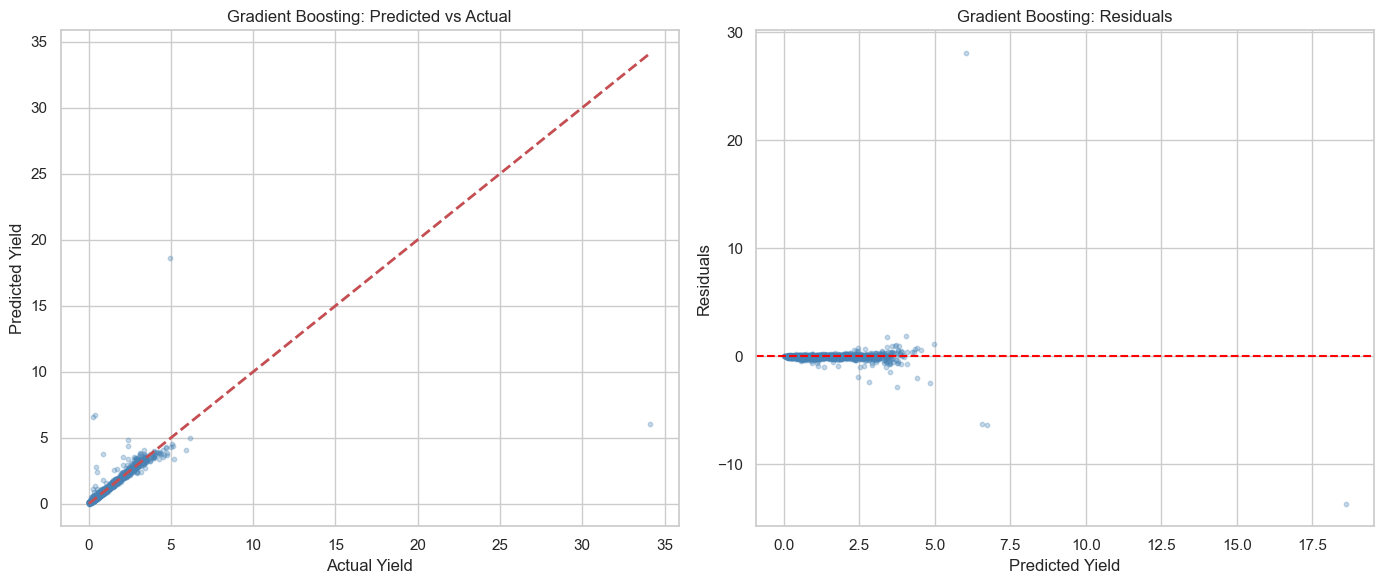

Best model: Gradient Boosting


In [27]:
# Use the best model (highest R²)
best_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
best_preds = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Yield')
axes[0].set_ylabel('Predicted Yield')
axes[0].set_title(f'{best_name}: Predicted vs Actual')

residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Yield')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'{best_name}: Residuals')

plt.tight_layout()
plt.show()
print(f"Best model: {best_name}")

## 6. Cross-Validation (5-Fold)

In [24]:
print("5-Fold Cross-Validation R² scores:\n")
for name, model_obj in models.items():
    cv_scores = cross_val_score(model_obj, X, y, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name:25s} | Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Cross-Validation R² scores:

Linear Regression         | Mean R²: 0.9695 ± 0.0437
Ridge Regression          | Mean R²: 0.9695 ± 0.0437
Gradient Boosting         | Mean R²: 0.8563 ± 0.1618


## 7. Learning Curves — Random Forest

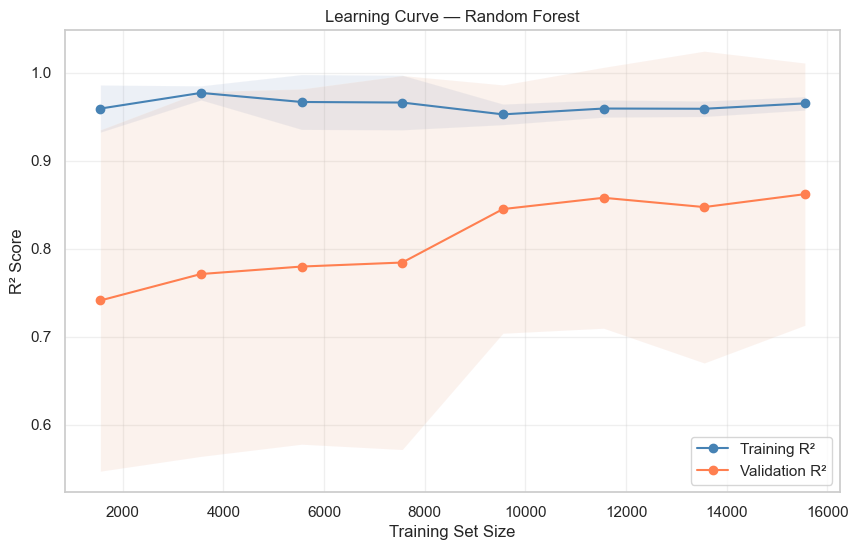

In [25]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
train_sizes, train_scores, val_scores = learning_curve(
    rf, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='r2'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training R²', color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation R²', color='coral')
plt.fill_between(train_sizes, train_scores.mean(axis=1)-train_scores.std(axis=1), train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1), val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve — Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary

The model comparison table shows which algorithm performs best on this dataset. The time-based split ensures no future data leaks into training. Cross-validation provides a more robust estimate of model performance.